# Tensorflow/Keras model architecture visualizations


In [1]:
# Make the project package importable when this folder is the working directory.
import sys
from pathlib import Path

for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "src").is_dir():
        sys.path.insert(0, str(candidate))
        break

from IPython.display import display
from src.visualisations.viz_keras_model import (
    export_publication_figures,
    find_project_root,
    load_keras_models,
    notebook_preview,
    render_graph_view,
    render_layered_overview,
)

2026-07-31 13:02:09.253823: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Load the saved models

Edit this dictionary when model names or locations change.

In [2]:
PROJECT_ROOT = find_project_root()
MODEL_PATHS = {
    "CNN": PROJECT_ROOT / "models/cnn_v2_sel_feats/cnn_v2_sel_feats_finetuned.keras",
    "DNN": PROJECT_ROOT / "models/dnn_v2_sel_feats/dnnv2_vts_finetuned_finetuned.keras",
    "Logistic regression": PROJECT_ROOT / "models/logistic_regression_tf_SGD/logistic_regression_tf_SGD_finetuned.keras",
}

models = load_keras_models(MODEL_PATHS)
for name, model in models.items():
    print(f"{name}: {model.name!r}, {len(model.layers)} serialized layers")

CNN: 'cnn_v2_sel_feats', 52 serialized layers
DNN: 'dnn_v2_selected_features', 28 serialized layers
Logistic regression: 'sequential', 1 serialized layers


## Layered architecture figures

This wrapper contains the choices most likely to change: displayed layers, custom labels, legend categories, spacing, titles, and captions. Layer indices refer to model.layers.

In [3]:
def create_layered_figures(loaded_models):
    """Create the three simplified, presentation-ready layered views."""
    return {
        "cnn_v2_layered_overview": render_layered_overview(
            loaded_models["CNN"],
            title="CNN architecture overview (layered)",
            subtitle=(
                "Tensor dimensions exclude the batch axis. Global-average and "
                "global-max pooling operate in parallel before concatenation."
            ),
            # Show feature fusion, convolutions, pooling, and the dense head.
            layer_indices=[21, 23, 24, 28, 29, 33, 34, 38, 39, 43, 44, 45, 46, 47, 51],
            label_overrides={
                "numeric_plus_categorical_embeddings": (
                    "Feature merge\n12 numeric + 5 embeddings\n37 features"
                )
            },
            legend_categories=["merge", "convolution", "pooling", "dense"],
            spacing=110,
        ),
        "dnn_v2_layered_overview": render_layered_overview(
            loaded_models["DNN"],
            title="FFNN architecture overview (layered)",
            subtitle=(
                "Five categorical embeddings are merged with 12 numeric features, "
                "then processed by a 256-unit dense block and sigmoid output."
            ),
            # The FFNN (DNN) is short enough to show every layer after feature fusion.
            layer_indices=list(range(21, 28)),
            label_overrides={
                "numeric_plus_categorical_embeddings": (
                    "Feature merge\n12 numeric + 5 embeddings\n32 features"
                )
            },
            legend_categories=["merge", "transform", "regularization", "dense"],
            spacing=120,
        ),
        "logistic_regression_layered_overview": render_layered_overview(
            loaded_models["Logistic regression"],
            title="Logistic regression architecture overview (layered)",
            subtitle=(
                "A 190-feature input vector feeds one sigmoid unit; the output is "
                "the predicted readmission probability."
            ),
            # Restore the implicit InputLayer hidden by Sequential.layers.
            include_input_layer=True,
            legend_categories=["input", "dense"],
            spacing=180,
        ),
    }

cnn_v2_layered_overview


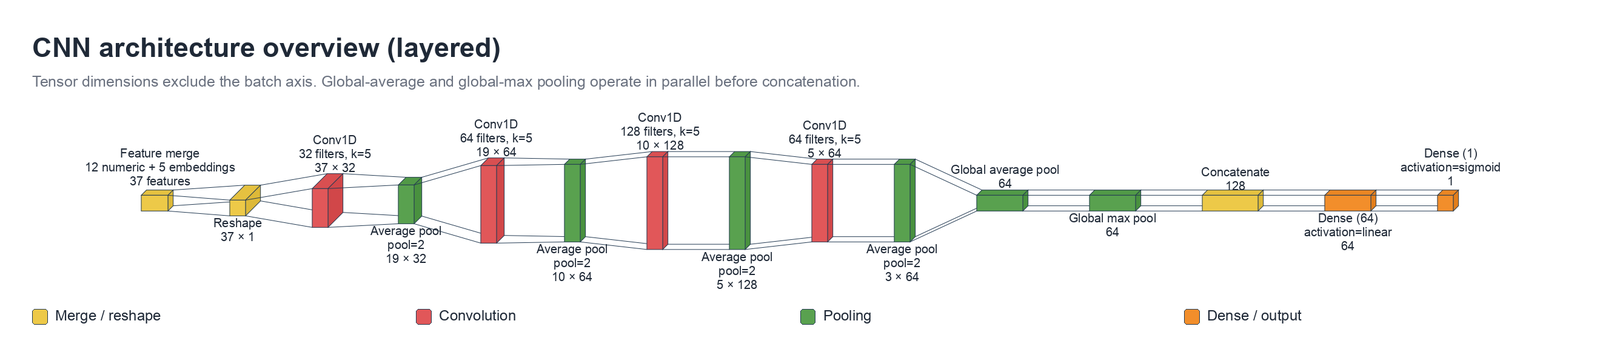

dnn_v2_layered_overview


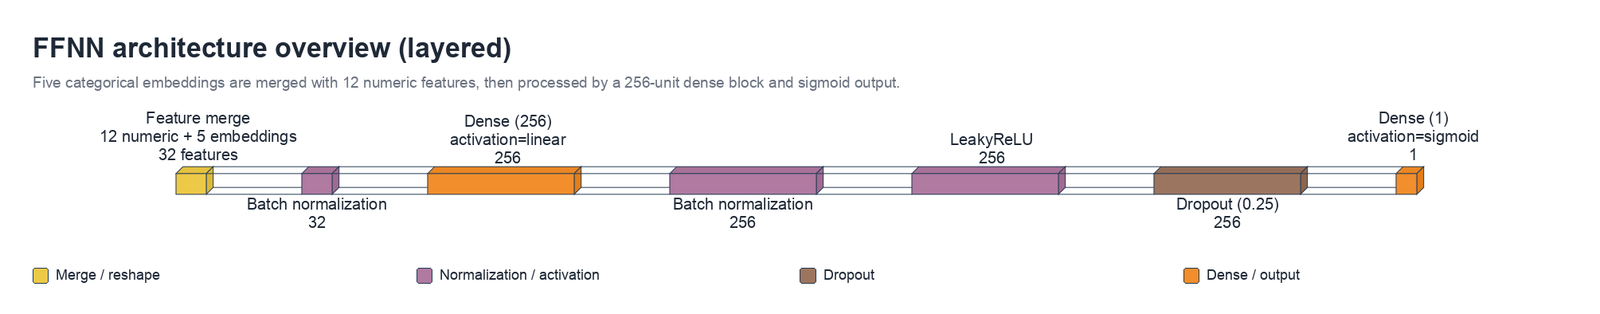

logistic_regression_layered_overview


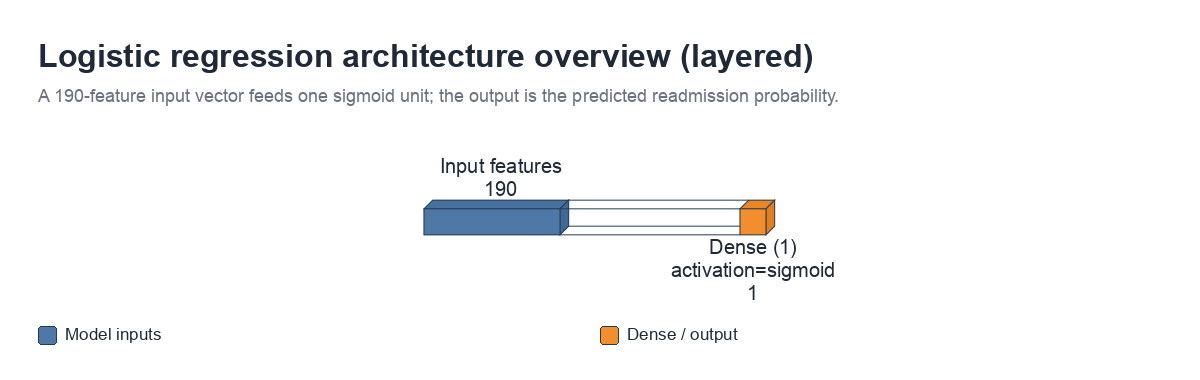

In [4]:
layered_figures = create_layered_figures(models)
for name, figure in layered_figures.items():
    print(name)
    display(notebook_preview(figure))

## Detailed Graph figures

In [5]:
GRAPH_SETTINGS = {
    "CNN": {
        "filename": "cnn_v2_exact_graph",
        "title": "CNN Architecture Graph",
        "subtitle": (
            "Six input branches feed categorical encoding and feature fusion, "
            "followed by four convolutional blocks and a dense classifier."
        ),
        "stages": [
            (0, 3, "Inputs & encoding"),
            (4, 6, "Feature fusion"),
            (7, 11, "Conv block 1"),
            (12, 16, "Conv block 2"),
            (17, 21, "Conv block 3"),
            (22, 26, "Conv block 4"),
            (27, 28, "Global pooling"),
            (29, 34, "Dense classifier"),
        ],
        "legend_categories": None,  # Show every semantic category.
    },
    "DNN": {
        "filename": "dnn_v2_exact_graph",
        "title": "FFNN Architecture Graph",
        "subtitle": (
            "Six input branches are encoded and merged before normalization, "
            "a dense feature block, dropout, and binary classification."
        ),
        "stages": [
            (0, 3, "Inputs & encoding"),
            (4, 5, "Feature fusion"),
            (6, 11, "Dense classifier"),
        ],
        "legend_categories": [
            "input", "encoding", "merge", "transform",
            "regularization", "dense",
        ],
    },
    "Logistic regression": {
        "filename": "logistic_regression_exact_graph",
        "title": "Logistic regression Architecture Graph",
        "subtitle": (
            "A 190-feature input tensor feeds one sigmoid output unit trained "
            "with stochastic gradient descent."
        ),
        "stages": [(0, 0, "Input"), (1, 2, "Linear classifier")],
        "legend_categories": ["input", "dense"],
    },
}


cnn_v2_exact_graph


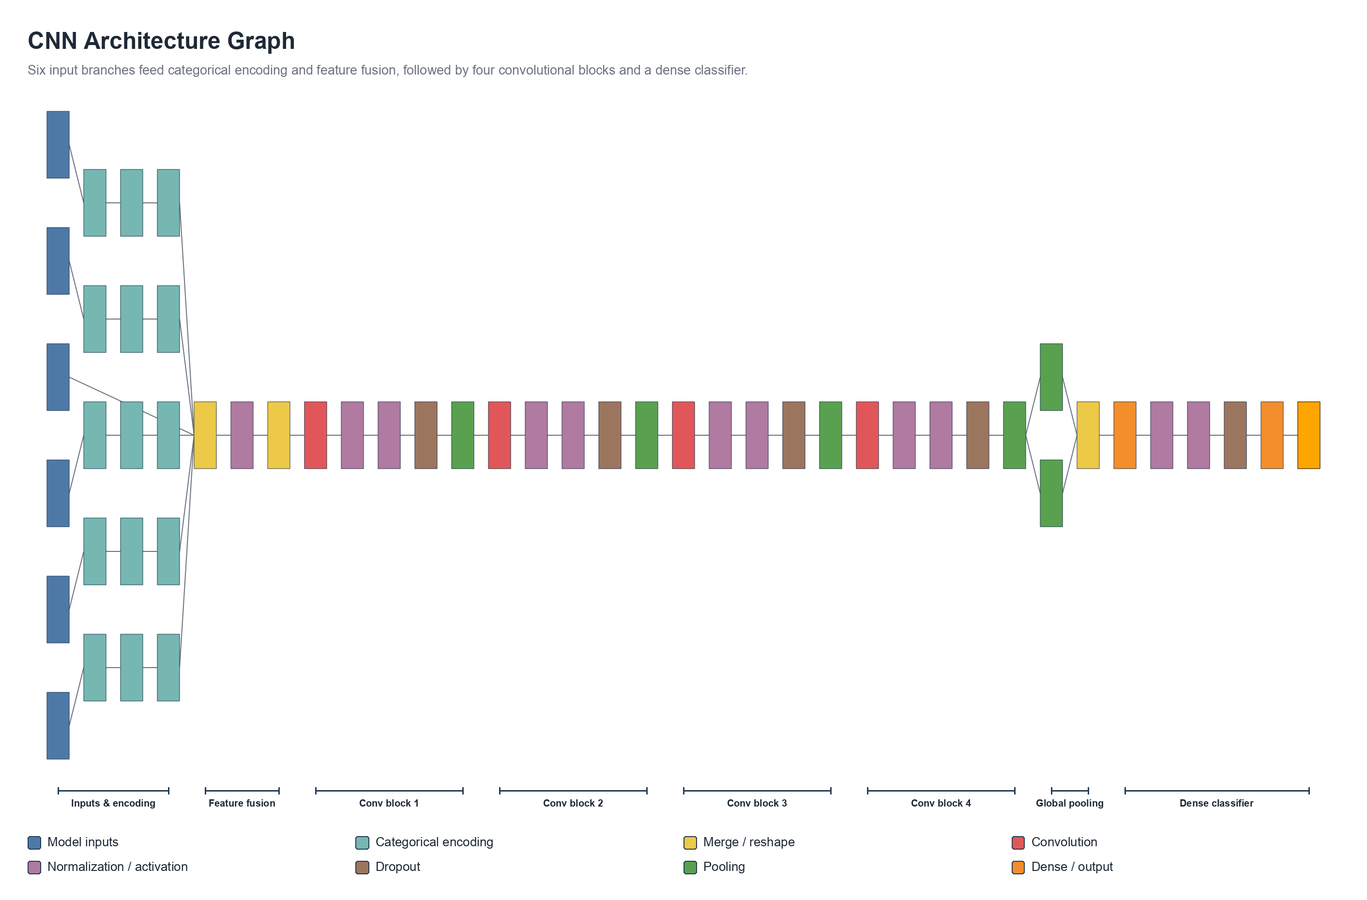

dnn_v2_exact_graph


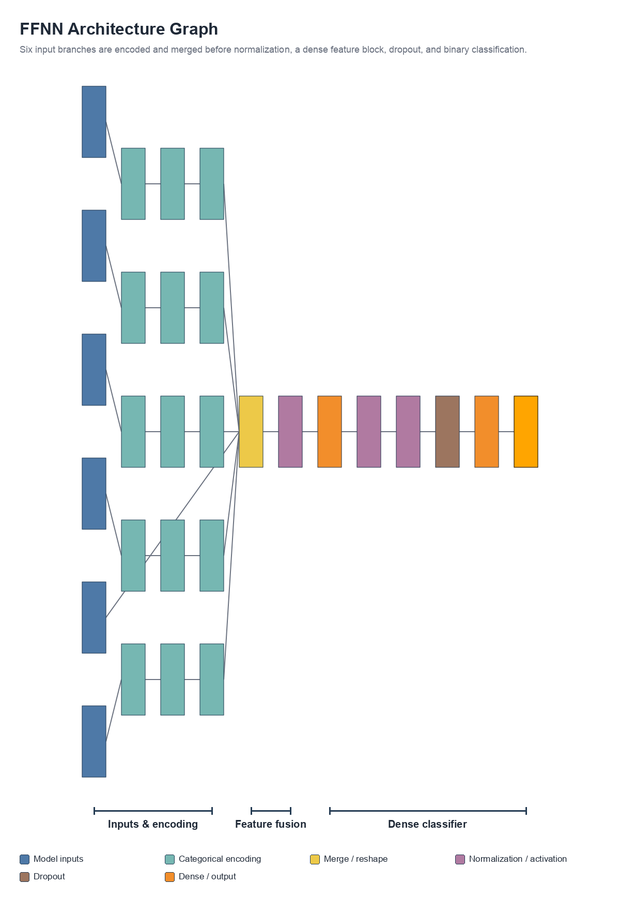

logistic_regression_exact_graph


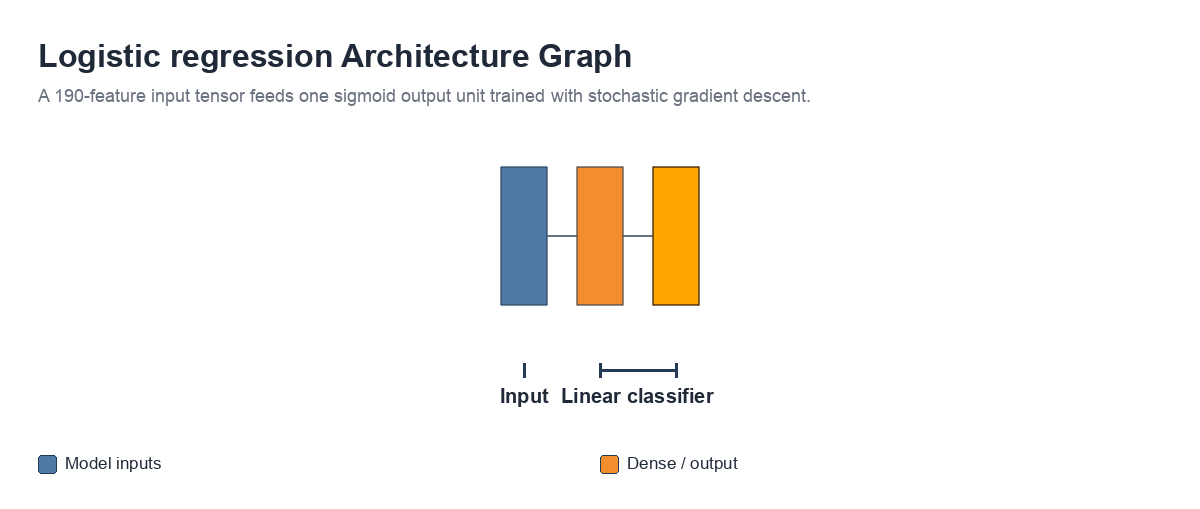

In [6]:
def create_graph_figures(loaded_models, settings):
    """Create exact graph views using the editable settings above."""
    figures = {}
    for model_name, options in settings.items():
        figures[options["filename"]] = render_graph_view(
            loaded_models[model_name],
            title=options["title"],
            subtitle=options["subtitle"],
            stages=options["stages"],
            legend_categories=options["legend_categories"],
        )
    return figures


graph_figures = create_graph_figures(models, GRAPH_SETTINGS)
for name, figure in graph_figures.items():
    print(name)
    display(notebook_preview(figure))

## Export final figures

This wrapper exports full-resolution 300-DPI report PNGs and 1920 × 1080 presentation PNGs.

In [7]:
def export_final_visualizations(layered, graphs):
    """Exporting every figure"""
    output_root = PROJECT_ROOT / "notebook/visualizing_tensorflow_models/architecture_images"
    exported = export_publication_figures({**layered, **graphs}, output_root)

    return exported

exported_files = export_final_visualizations(
    layered_figures,
    graph_figures
)
for figure_name, paths in exported_files.items():
    print(figure_name)
    print(f"  Report: {paths['report']}")
    print(f"  Presentation: {paths['presentation']}")


cnn_v2_layered_overview
  Report: /Users/vassilistsoubris/PycharmProjects/ds207_final_project/notebook/visualizing_tensorflow_models/architecture_images/report/cnn_v2_layered_overview.png
  Presentation: /Users/vassilistsoubris/PycharmProjects/ds207_final_project/notebook/visualizing_tensorflow_models/architecture_images/presentation/cnn_v2_layered_overview_1920x1080.png
dnn_v2_layered_overview
  Report: /Users/vassilistsoubris/PycharmProjects/ds207_final_project/notebook/visualizing_tensorflow_models/architecture_images/report/dnn_v2_layered_overview.png
  Presentation: /Users/vassilistsoubris/PycharmProjects/ds207_final_project/notebook/visualizing_tensorflow_models/architecture_images/presentation/dnn_v2_layered_overview_1920x1080.png
logistic_regression_layered_overview
  Report: /Users/vassilistsoubris/PycharmProjects/ds207_final_project/notebook/visualizing_tensorflow_models/architecture_images/report/logistic_regression_layered_overview.png
  Presentation: /Users/vassilistsoubri